# U23AI035 - LAB 2 - Responsible AI

### 1. Use the dataset in salary.zip to create a linear regression model. Split the dataset into training and test using a 70: 30 split. Find the Mean Squared Error on the test set. If you shuffle the data and then split using the mentioned splits, does it have an impact in the model? Show it by shuffling the data 5 times.

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [120]:
data = pd.read_csv('salary.csv')

In [121]:
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [122]:
data.shape

(30, 3)

In [123]:
data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


In [125]:
x = data['YearsExperience'].values.reshape(-1, 1)
y = data['Salary']

### Without Shuffling

In [126]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [127]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred = model.predict(x_test)

In [129]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 37784662.46621304


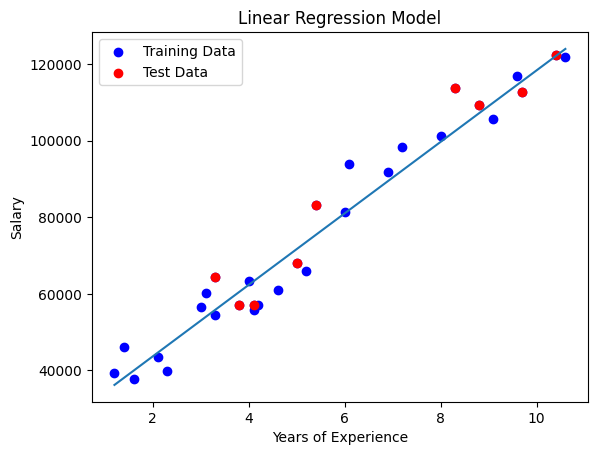

In [130]:
plt.scatter(x, y, color='blue', label='Training Data')
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line)
plt.scatter(x_test, y_test, color='red', label='Test Data')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Model")
plt.legend()
plt.show()

### Shuffling 5 times

In [131]:
mse_scores = []
for seed in range(5):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True, random_state=seed)

    model = LinearRegression()
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"Shuffle {seed+1} → MSE: {mse:.2f}")

Shuffle 1 → MSE: 23370078.80
Shuffle 2 → MSE: 39139216.00
Shuffle 3 → MSE: 64406629.39
Shuffle 4 → MSE: 31330529.37
Shuffle 5 → MSE: 37067848.91


### Verdict: Shuffling the dataset does not improve the result.

### 2. Use the dataset in salary.zip to create a linear regression model. Split the dataset into training and test using a 80: 20 split. Find the Mean Squared Error on the test set. As the dataset consists of different scales (units) for different columns, does normalization play a factor in the performance of the model? Use min-max scaling and standard normalization to show the impact of normalization.

In [132]:
data = pd.read_csv('student.csv')

In [133]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Without Normalization

In [134]:
data.shape

(10000, 6)

In [135]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [136]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [137]:
x = data.drop('Performance Index', axis=1)
y = data['Performance Index']

In [138]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [139]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [140]:
y_pred = model.predict(x_test)

In [141]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 4.082628398521853


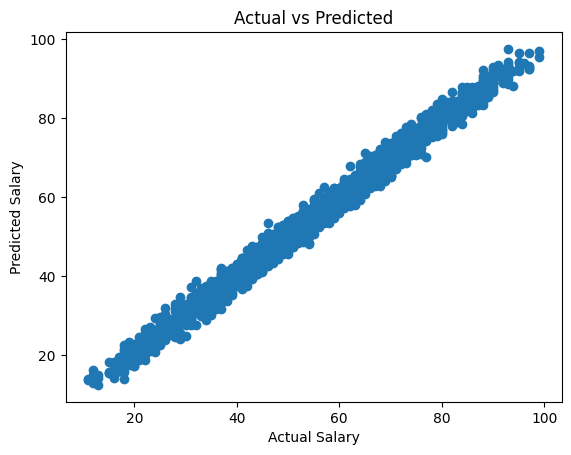

In [142]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

### Min-Max Scalling

In [143]:
minmax_scaler = MinMaxScaler()
x_train_minmax = minmax_scaler.fit_transform(x_train)
x_test_minmax = minmax_scaler.transform(x_test)

In [144]:
model_minmax = LinearRegression()
model_minmax.fit(x_train_minmax, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [145]:
y_pred_minmax = model_minmax.predict(x_test_minmax)
mse_minmax = mean_squared_error(y_test, y_pred_minmax)
print("Min-Max Scaled MSE:", mse_minmax)

Min-Max Scaled MSE: 4.082628398521855


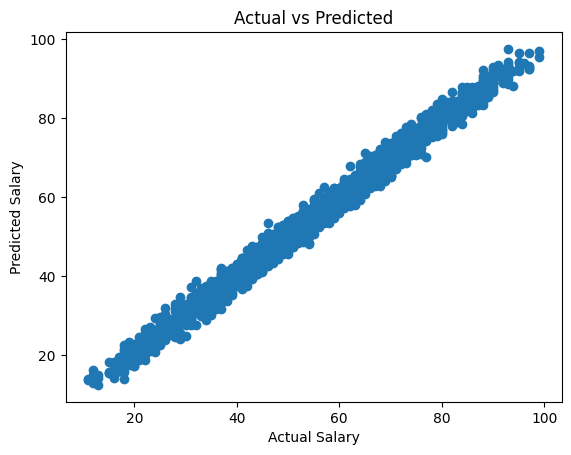

In [146]:
plt.scatter(y_test, y_pred_minmax)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

### Standardization

In [147]:
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(x_train)
X_test_std = std_scaler.transform(x_test)

In [148]:
model_std = LinearRegression()
model_std.fit(X_train_std, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [149]:
y_pred_std = model_std.predict(X_test_std)
mse_std = mean_squared_error(y_test, y_pred_std)
print("Standardized MSE:", mse_std)

Standardized MSE: 4.082628398521842


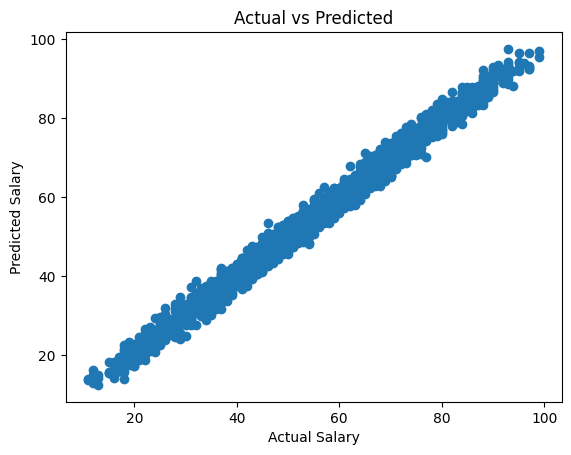

In [150]:
plt.scatter(y_test, y_pred_std)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()